In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xbudget
import regionate
import xwmt
import xwmb
import xgcm
import cartopy.crs as ccrs
import xesmf as xe
import CM4Xutils #needed to run pip install nc-time-axis
from regionate import MaskRegions, GriddedRegion
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *

In [7]:
def extract_tracer_at_coord_extreme(coord_1d, tracer_1d, mode='min'):
    """Extract tracer value at coordinate extreme, handling NaNs properly."""
    # Create mask for valid (non-NaN) values in both coord and tracer
    valid_coord = ~np.isnan(coord_1d)
    valid_tracer = ~np.isnan(tracer_1d)
    valid_both = valid_coord & valid_tracer
    
    # If no valid pairs, return NaN
    if not np.any(valid_both):
        return np.nan
    
    # Find extremum among valid coordinate values where tracer is also valid
    valid_coords = coord_1d[valid_both]
    valid_tracers = tracer_1d[valid_both]
    
    if mode == 'min':
        extreme_idx = np.argmin(valid_coords)
    elif mode == 'max':
        extreme_idx = np.argmax(valid_coords)
    else:
        raise ValueError(f"Mode must be 'min' or 'max', got '{mode}'")
    
    return valid_tracers[extreme_idx]


def extract_tracers_at_coord_extreme(ds, coord_name = "sigma2_l", mode='min', suffix=None):
    """
    Extract all tracers at coordinate extreme for each profile.
    
    Parameters
    ----------
    ds : xr.Dataset
        Dataset with tracer variables and coordinates
    coord_name : str
        Coordinate variable name to find extremum of
    mode : str, default 'min'
        Either 'min' for minimum coordinate or 'max' for maximum
    suffix : str, optional
        Custom suffix for output variable names. If None, uses "{mode}"
        
    Returns
    -------
    xr.Dataset
        Variables at extremum coordinate with custom naming
    """
    if mode not in ['min', 'max']:
        raise ValueError(f"Mode must be 'min' or 'max', got '{mode}'")
    
    if coord_name not in ds:
        raise ValueError(f"Coordinate '{coord_name}' not found in dataset")
    
    # Set default suffix if not provided
    if suffix is None:
        suffix = mode
    
    coord = ds[coord_name]
    result = {}
    
    for var_name, tracer in ds.data_vars.items():
        if var_name == coord_name:
            continue
            
        # Check if the tracer has the required coordinate dimension
        if coord_name not in tracer.dims:
            print(f"Warning: Variable '{var_name}' does not have dimension '{coord_name}', skipping...")
            continue
            
        # Custom naming: just add suffix
        output_var = xr.apply_ufunc(
            extract_tracer_at_coord_extreme,
            coord, tracer, mode,
            input_core_dims=[[coord_name], [coord_name], []],
            output_core_dims=[[]],
            vectorize=True,
            dask="parallelized",
            output_dtypes=[tracer.dtype]
        )
        
        # Add the method as a coordinate
        output_var = output_var.expand_dims(sort_method = [f"{mode}imum"])
        result[f"{var_name}"] = output_var
        result[f"{var_name}"].attrs.update(ds[f"{var_name}"].attrs)
    return xr.Dataset(result)


In [5]:
savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
savename = savedir + f"Column_Tracer_Samples_On_Sigma_Example.nc"
combined_ds_samp = xr.open_dataset(savename)

In [8]:
ds_samples_at_min_density = extract_tracers_at_coord_extreme(combined_ds_samp, coord_name = "sigma2_l", mode = "min")
ds_samples_at_max_density = extract_tracers_at_coord_extreme(combined_ds_samp, coord_name = "sigma2_l", mode = "max")

In [9]:
ds_samples_at_density_extrema = xr.concat([ds_samples_at_min_density, ds_samples_at_max_density], 
                                          dim="sort_method", combine_attrs = "identical")

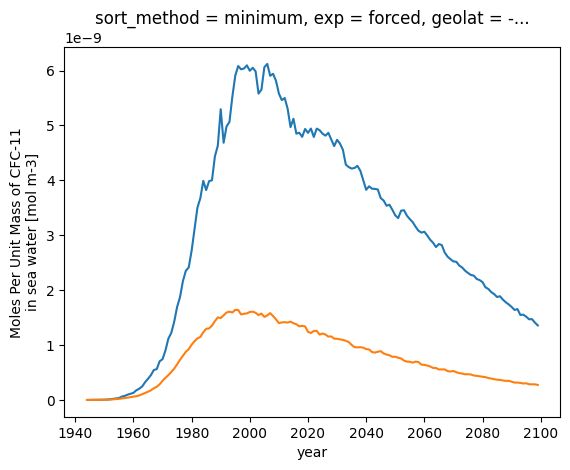

In [13]:
ds_samples_at_density_extrema.sel(exp = "forced", sort_method = "minimum").isel(locations = 1).cfc11.groupby("time.year").mean("time").plot()
ds_samples_at_density_extrema.sel(exp = "forced", sort_method = "minimum").isel(locations = 0).cfc11.groupby("time.year").mean("time").plot()

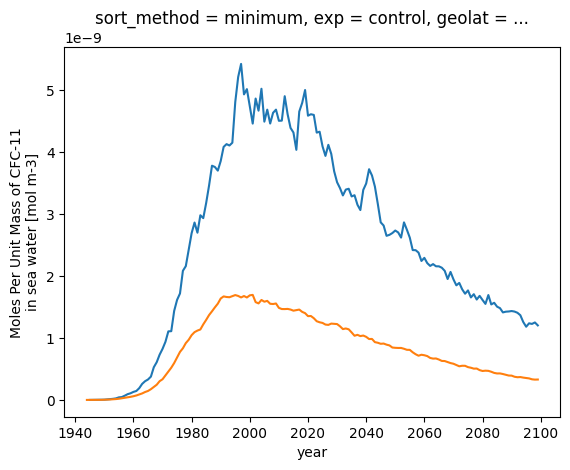

In [14]:
ds_samples_at_density_extrema.sel(exp = "control", sort_method = "minimum").isel(locations = 1).cfc11.groupby("time.year").mean("time").plot()
ds_samples_at_density_extrema.sel(exp = "control", sort_method = "minimum").isel(locations = 0).cfc11.groupby("time.year").mean("time").plot()

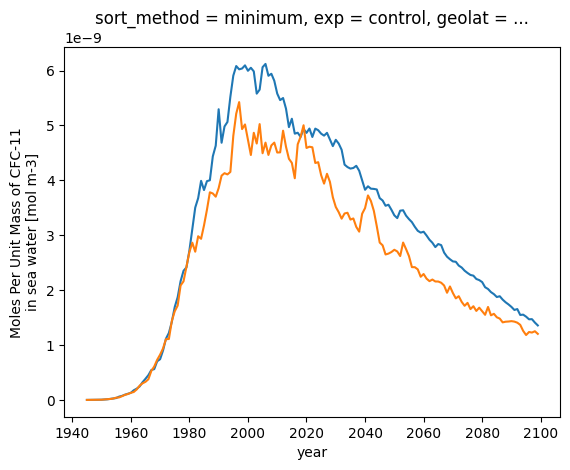

In [10]:
ds_samples_at_density_extrema.sel(exp = "forced", sort_method = "minimum").isel(locations = 1).cfc11.groupby("time.year").mean("time").plot()
ds_samples_at_density_extrema.sel(exp = "control", sort_method = "minimum").isel(locations = 1).cfc11.groupby("time.year").mean("time").plot()

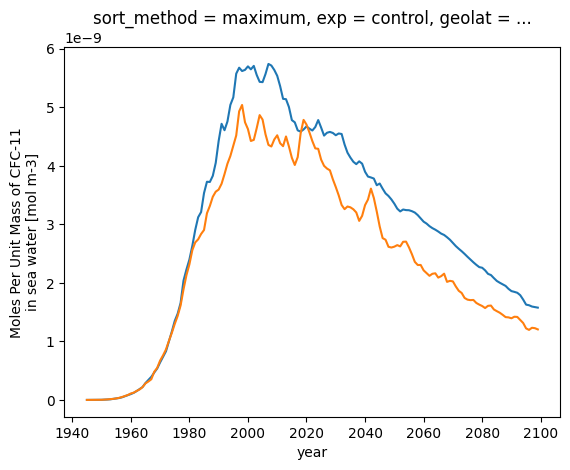

In [12]:
ds_samples_at_density_extrema.sel(exp = "forced", sort_method = "maximum").isel(locations = 0).cfc11.groupby("time.year").mean("time").plot()
ds_samples_at_density_extrema.sel(exp = "control", sort_method = "maximum").isel(locations = 0).cfc11.groupby("time.year").mean("time").plot()

In [23]:
renam_ds_samples_at_density_extrema = ds_samples_at_density_extrema.assign_coords(locations = np.array(["near_equator", "near_ross"], dtype = "object"))

In [45]:
ds_description = ("These are time samples taken at two locations from the CM4Xp125"
"(1/8 degree) 'control' and 'forced scenarios." 
"The sample locations were selected from a visual analysis of a plot of "
"CFC-11 bottom spreading and surface water mass transformation, "
"one near the equator (5°S, 177°W) and another near the Ross Sea (77°S, 177°W)."
"The visual analysis suggests that these points may be connected, although there are no guarantees."
" The samples were further subset to only include the surface and bottom points at both locations,"
" as indicated by the \'sort_method\' dimension with \'maximum\' corresponding the densest water and \'minimum\' to the lightest.")
renam_ds_samples_at_density_extrema.attrs["description"] = ds_description

In [47]:
savedir = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/"
savename = savedir + f"Column_Tracer_Samples_On_Sigma_Extema_Example.nc"
renam_ds_samples_at_density_extrema.to_netcdf(savename)